## Group 2 - Project Demo 2

**Dataset**: https://www.kaggle.com/datasets/niloy333/kuhar/data

**Group name**: HAR-Core

**Group members**:

Thuan Lam (thuan.lam@sjsu.edu)

Harshit Jaglan (harshit.jaglan@sjsu.edu)

Ynha Nguyen (y-nha.nguyen@sjsu.edu)

Thy Tran (thy.a.tran01@sjsu.edu)

Marl Jonson (marlfarris.jonson@sjsu.edu)

## Human Activity Classification
**What problem are we solving?**

In this project, we aim to build a machine learning model that can classify different types of human activities using smartphone sensor data from the KU-HAR dataset. The problem we are addressing is how smartphones can automatically detect what activity a person is performing based on movement signals.

**What sensors or signals will we use?**

The dataset contains data from 90 participants performing 18 different activities. The data is recorded using a smartphone's accelerometer and gyroscope. The accelerometer measures body movement along the X, Y, and Z directions, while the gyroscope measures rotational motion around those same three axes. Using these motion signals, we will train a supervised multi-class classification model to learn patterns from each activity.

**What outcome to expect?**

The expected outcome is a model that can accurately predict the type of activity, such as sitting, walking, running, or climbing stairs, based on the motion data.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from scipy.signal import butter, filtfilt, medfilt


In [ ]:
import kagglehub
import os

# Download latest version of dataset
path = kagglehub.dataset_download("niloy333/kuhar")

csv_path = os.path.join(
    path,
    "3.Time_domain_subsamples",
    "KU-HAR_time_domain_subsamples_20750x300.csv"
)

Using Colab cache for faster access to the 'kuhar' dataset.


# Dataset Exploration (Thuan)
Create a summary table including participants, days, demographics, and total labels.

In [ ]:
# Create summary table
summary_df = pd.DataFrame({
    "Item": [
        "Dataset",
        "Domain",
        "Total participants",
        "Male participants",
        "Female participants",
        "Number of collection days",
        "Number of activity classes (total labels)",
        "Number of raw activity samples",
        "Number of time-domain subsamples",
        "Sensors used",
        "Sampling rate",
        "Duration of each subsample",
        "Features per subsample"
    ],
    "Value": [
        "KU-HAR: Human Activity Recognition Dataset (v1.0)",
        "Human Activity Recognition",
        90,
        75,
        15,
        "Not specified",
        18,
        1945,
        20750,
        "Smartphone accelerometer and gyroscope",
        "100 Hz",
        "3 seconds",
        "1800 values"
    ]
})
summary_df.style.hide(axis='index').set_properties(**{'text-align': 'center'})

Item,Value
Dataset,KU-HAR: Human Activity Recognition Dataset (v1.0)
Domain,Human Activity Recognition
Total participants,90
Male participants,75
Female participants,15
Number of collection days,Not specified
Number of activity classes (total labels),18
Number of raw activity samples,1945
Number of time-domain subsamples,20750
Sensors used,Smartphone accelerometer and gyroscope


In [ ]:
# Create a class labels table
class_df = pd.DataFrame({
    "Class ID": list(range(18)),
    "Activity": [
        "Stand",
        "Sit",
        "Talk-sit",
        "Talk-stand",
        "Stand-sit",
        "Lay",
        "Lay-stand",
        "Pick",
        "Jump",
        "Push-up",
        "Sit-up",
        "Walk",
        "Walk-backward",
        "Walk-circle",
        "Run",
        "Stair-up",
        "Stair-down",
        "Table-tennis"
    ]
})
class_df.style.hide(axis='index').set_properties(**{'text-align': 'center'})

Class ID,Activity
0,Stand
1,Sit
2,Talk-sit
3,Talk-stand
4,Stand-sit
5,Lay
6,Lay-stand
7,Pick
8,Jump
9,Push-up


# Annotated Signal Exploration (Thuan)
Generate plots around labeled events and explain raw signal patterns.

In [ ]:
#Reading data:
df = pd.read_csv(csv_path, header=None)
dff = df.values
signals = dff[:, 0: 1800] #These are the time-domian subsamples (signals)
signals = np.array(signals, dtype=np.float32)
labels = dff[:, 1800] #These are their associated class labels (signals)

print(signals.shape)
print(labels.shape)

(20750, 1800)
(20750,)


In [ ]:
# Visualization of the random (time-domain HAR) sample (channel data):
# The corresponding activity is decided by label_id
def plot_label(signals, labels, label_id):
    class_samples = signals[labels == label_id]
    sample = class_samples[np.random.randint(len(class_samples))]

    Accelerometer_X_axis_data = sample[0: 300]
    Accelerometer_Y_axis_data = sample[300: 600]
    Accelerometer_Z_axis_data = sample[600: 900]
    Gyroscope_X_axis_data = sample[900: 1200]
    Gyroscope_Y_axis_data = sample[1200: 1500]
    Gyroscope_Z_axis_data = sample[1500: 1800]
    time = np.linspace(.01, 3, 300)

    figure(figsize=(12, 35), dpi=80)

    ax1 = plt.subplot(611)
    ax1.plot(time, Accelerometer_X_axis_data, 'b')
    ax1.title.set_text('Accelerometer X axis')
    ax1.set_xlabel('time (ms) ->')
    ax1.set_ylabel('Acceleration (m/s^2)')
    ax1.grid(True)

    ax2 = plt.subplot(612)
    ax2.plot(time, Accelerometer_Y_axis_data, 'g')
    ax2.title.set_text('Accelerometer Y axis')
    ax2.set_xlabel('time (ms) ->')
    ax2.set_ylabel('Acceleration (m/s^2)')
    ax2.grid(True)

    ax3 = plt.subplot(613)
    ax3.plot(time, Accelerometer_Z_axis_data, 'r')
    ax3.title.set_text('Accelerometer Z axis')
    ax3.set_xlabel('time (ms) ->')
    ax3.set_ylabel('Acceleration (m/s^2)')
    ax3.grid(True)

    ax4 = plt.subplot(614)
    ax4.plot(time, Gyroscope_X_axis_data, 'b')
    ax4.title.set_text('Gyroscope X axis')
    ax4.set_xlabel('time (ms) ->')
    ax4.set_ylabel('Angular rotation (rad/s)')
    ax4.grid(True)

    ax5 = plt.subplot(615)
    ax5.plot(time, Gyroscope_Y_axis_data, 'g')
    ax5.title.set_text('Gyroscope Y axis')
    ax5.set_xlabel('time (ms) ->')
    ax5.set_ylabel('Angular rotation (rad/s)')
    ax5.grid(True)

    ax6 = plt.subplot(616)
    ax6.plot(time, Gyroscope_Z_axis_data, 'r')
    ax6.title.set_text('Gyroscope Z axis')
    ax6.set_xlabel('time (ms) ->')
    ax6.set_ylabel('Angular rotation (rad/s)')
    ax6.grid(True)

    plt.show()

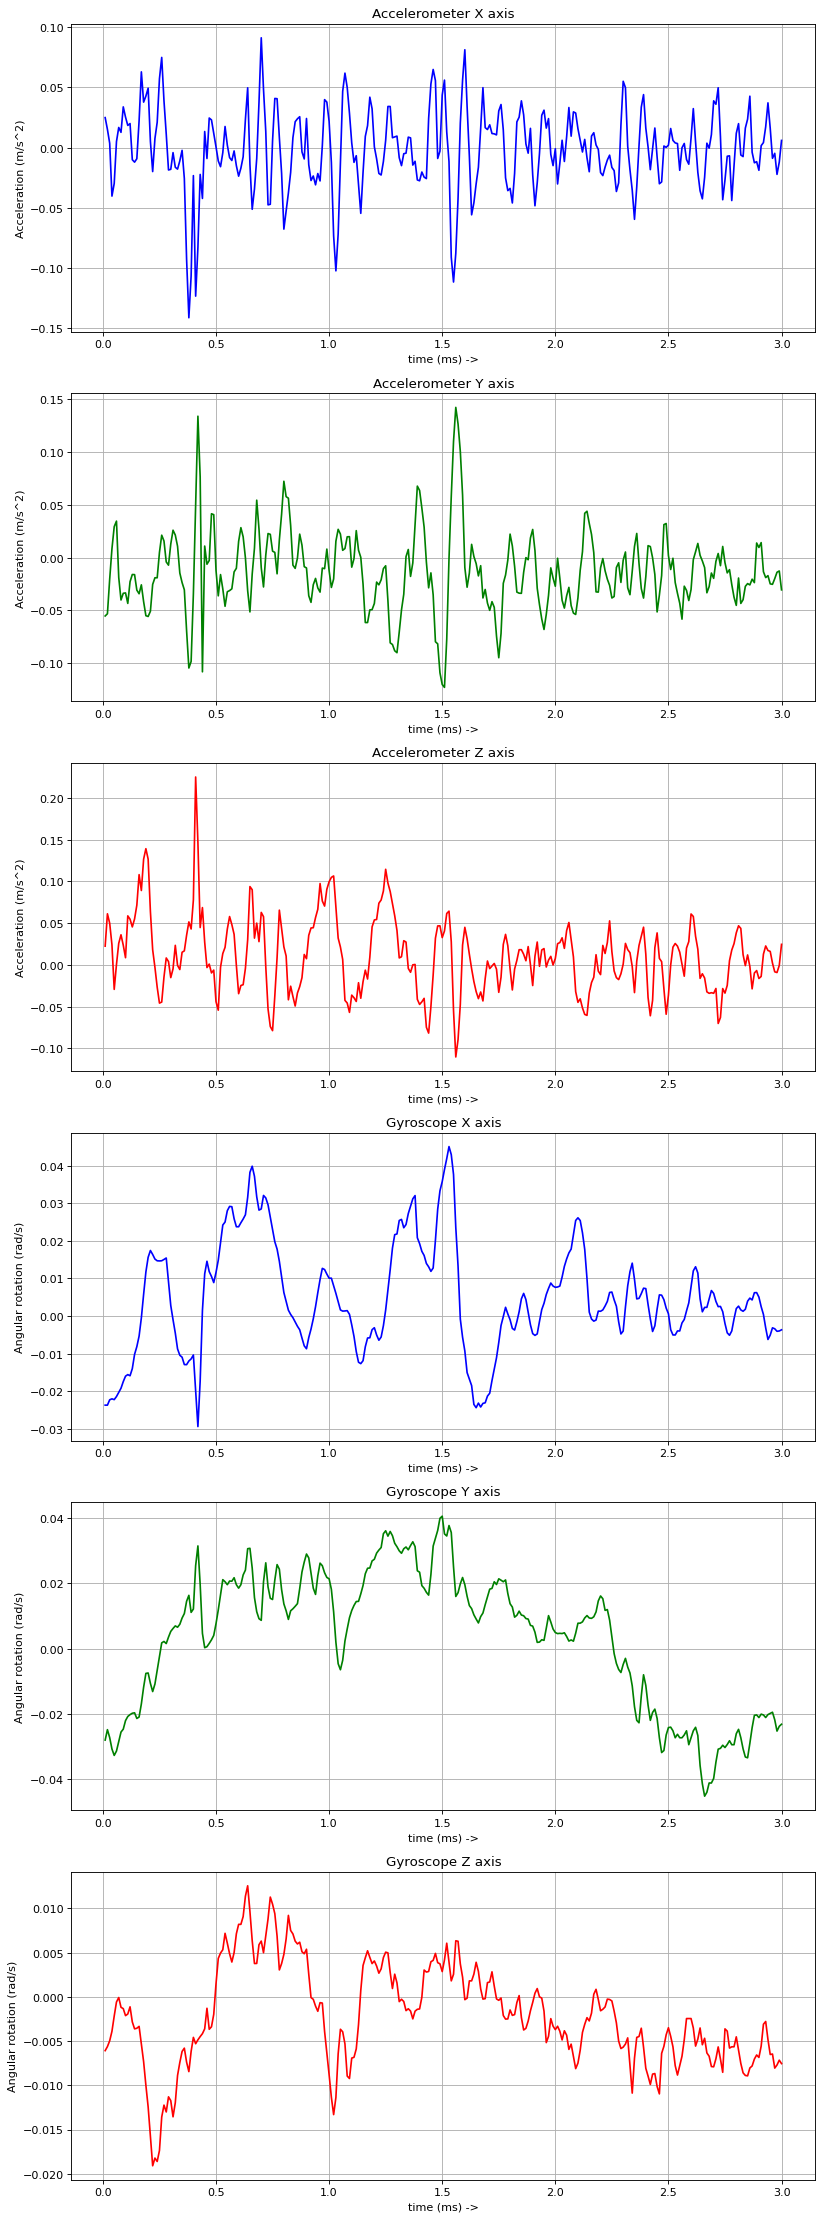

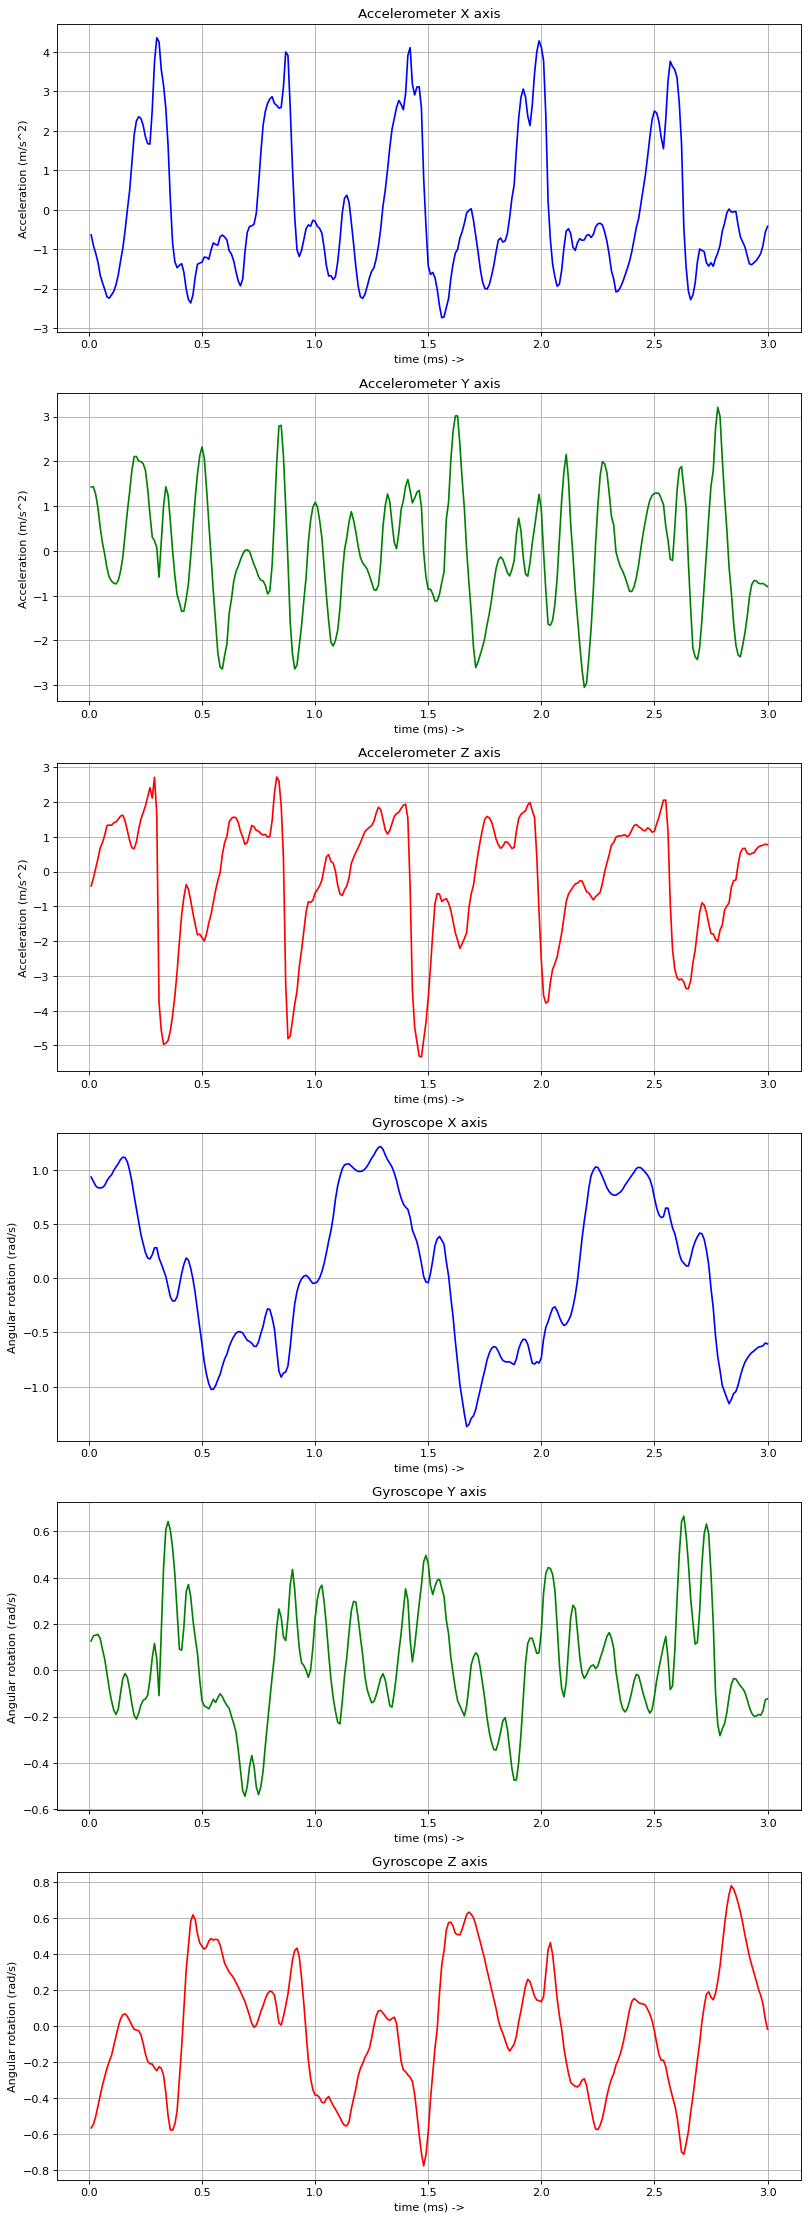

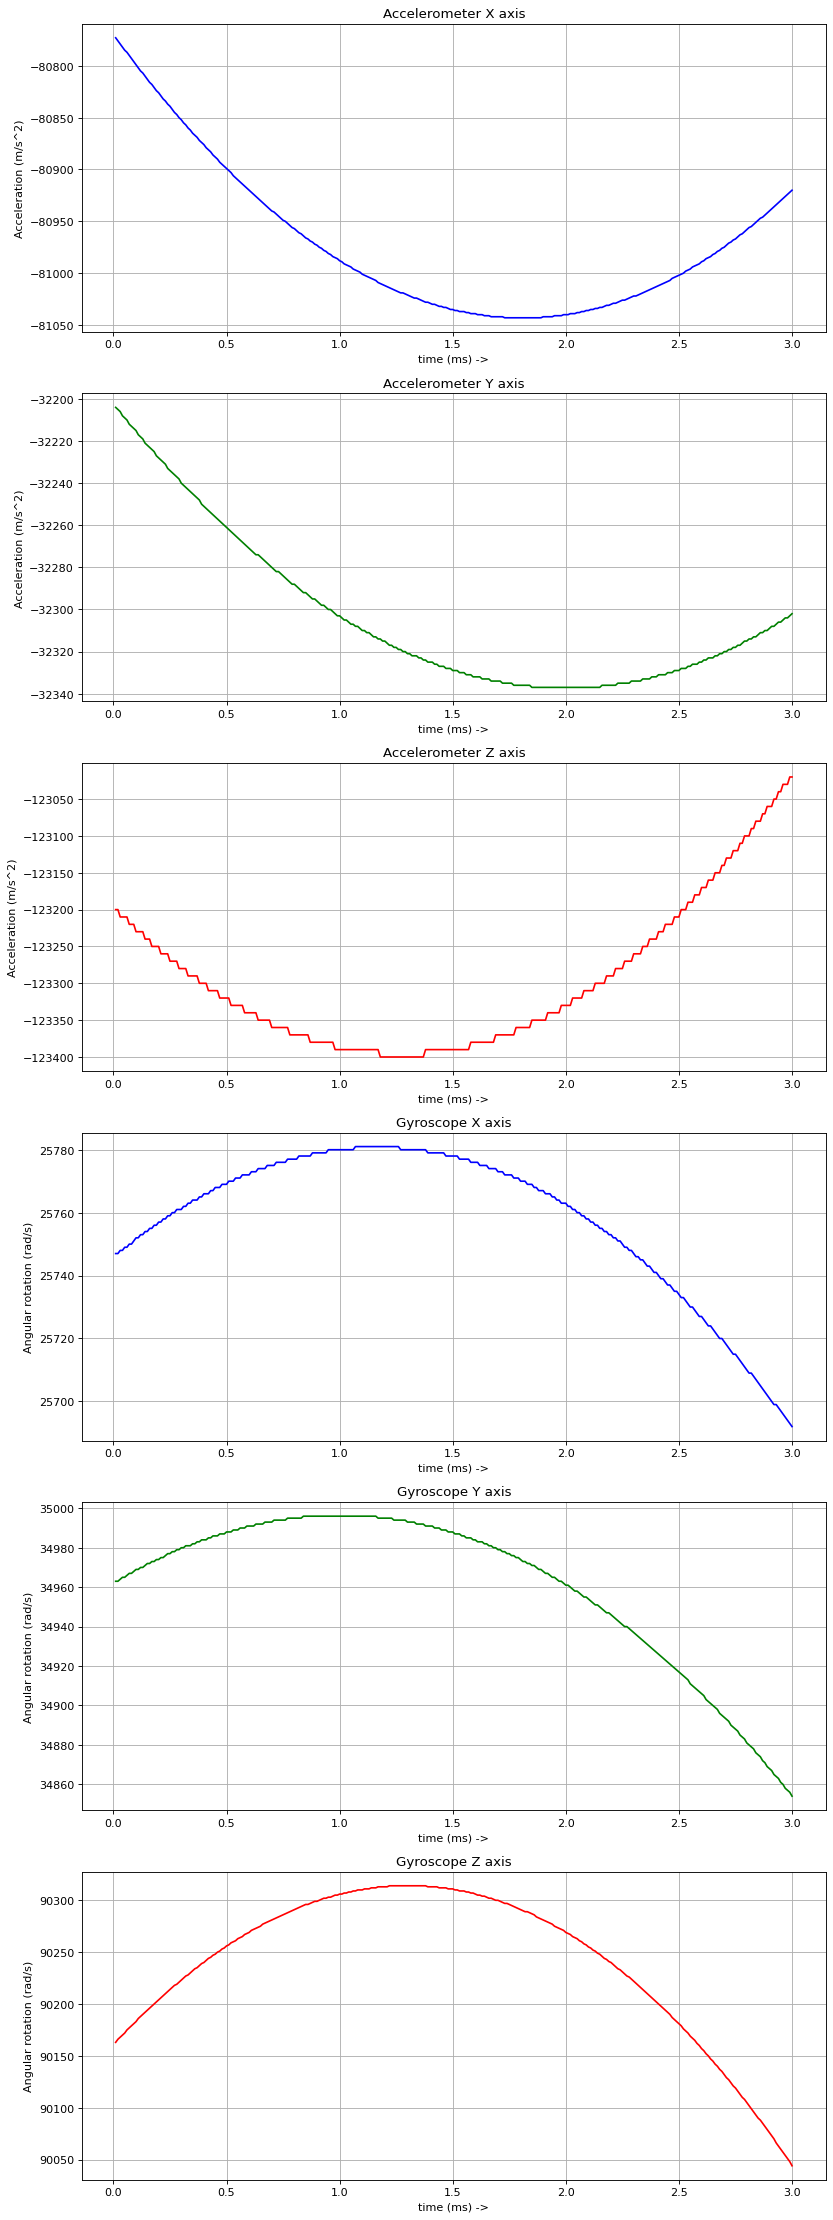

In [ ]:
# Compare Sit pattern vs Walk pattern vs Run pattern
plot_label(signals, labels, 0)
plot_label(signals, labels, 11)
plot_label(signals, labels, 14)

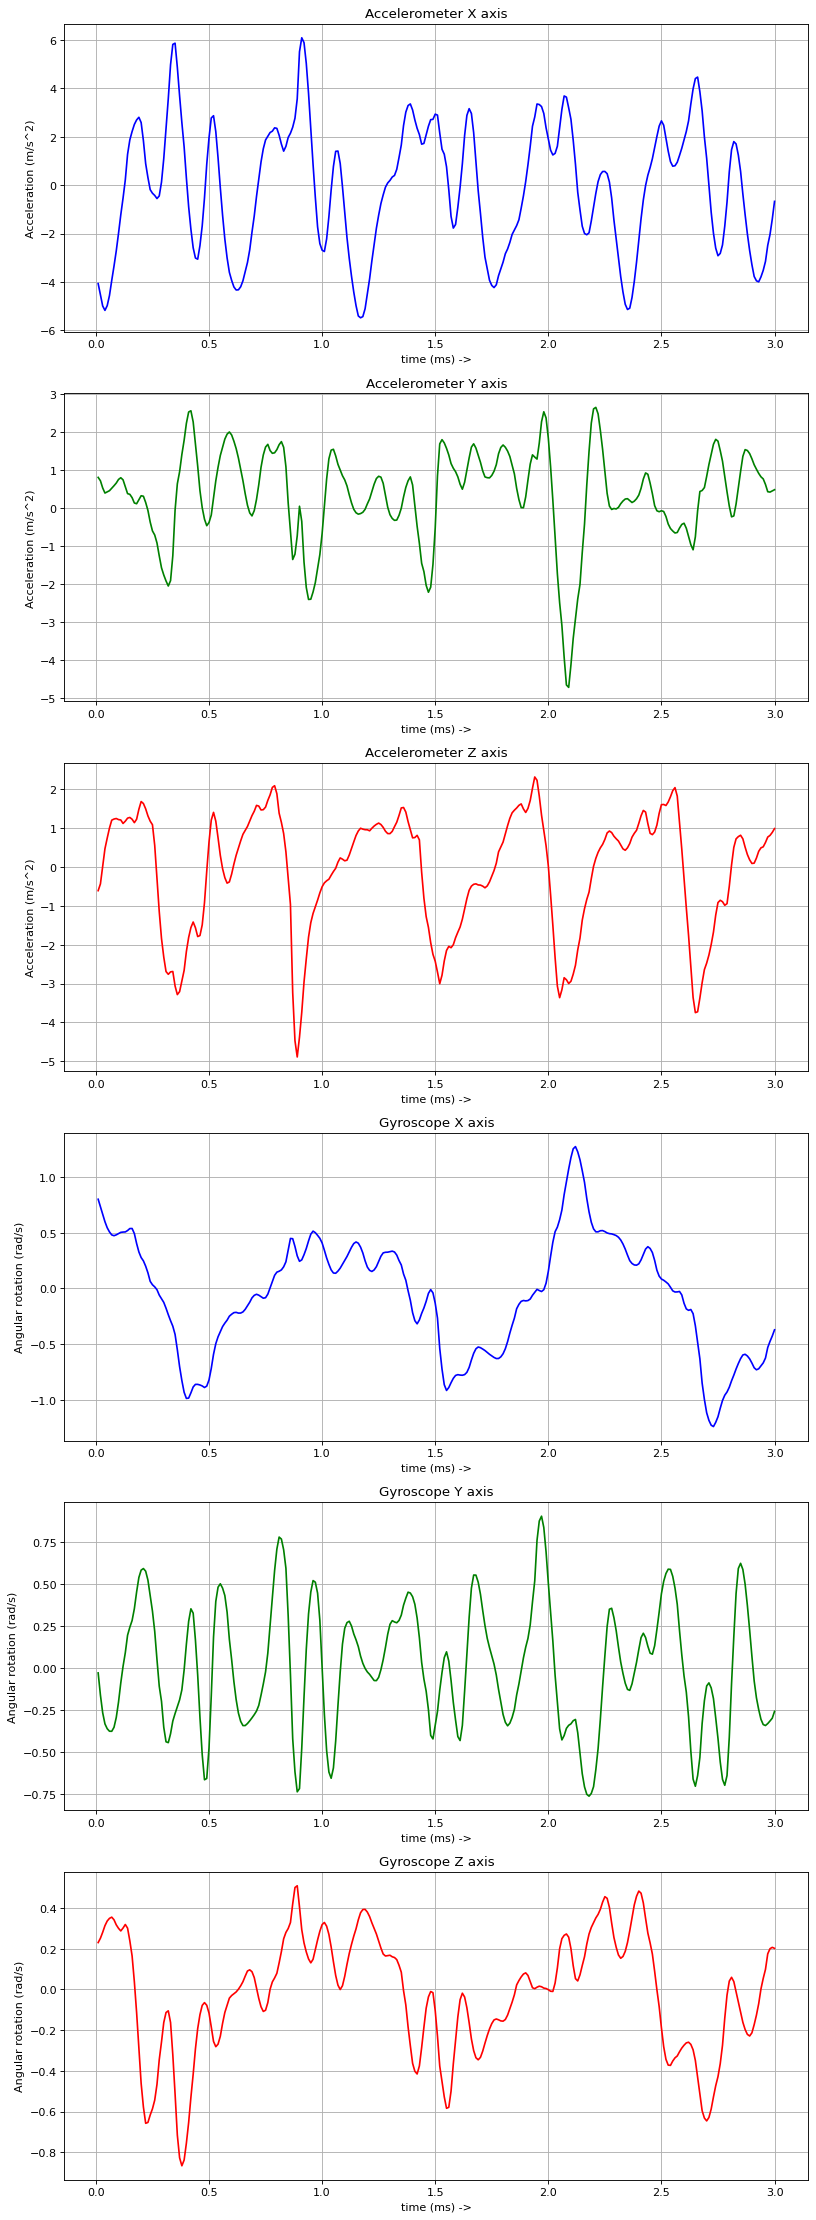

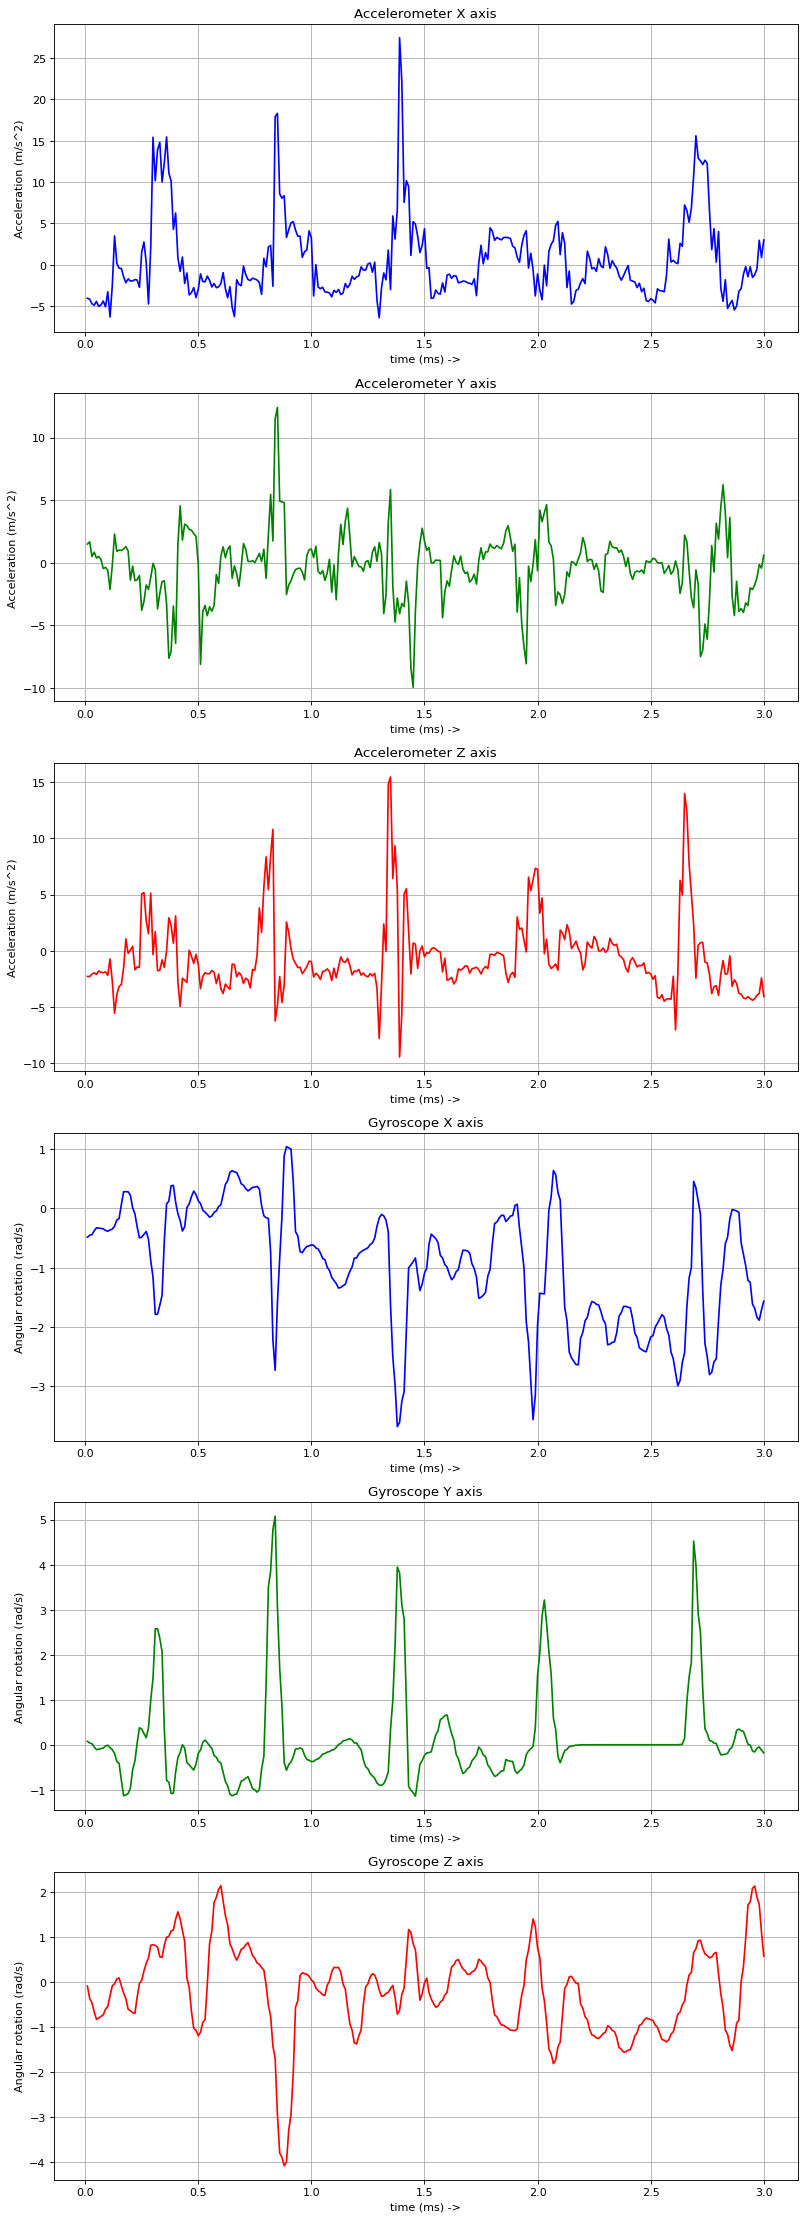

In [ ]:
# Compare Stair-up pattern vs Stair-down pattern
plot_label(signals, labels, 15)
plot_label(signals, labels, 16)

# Signal Preprocessing (Harshit)
Perform filtering, interpolation, before/after plots, and preprocessing.

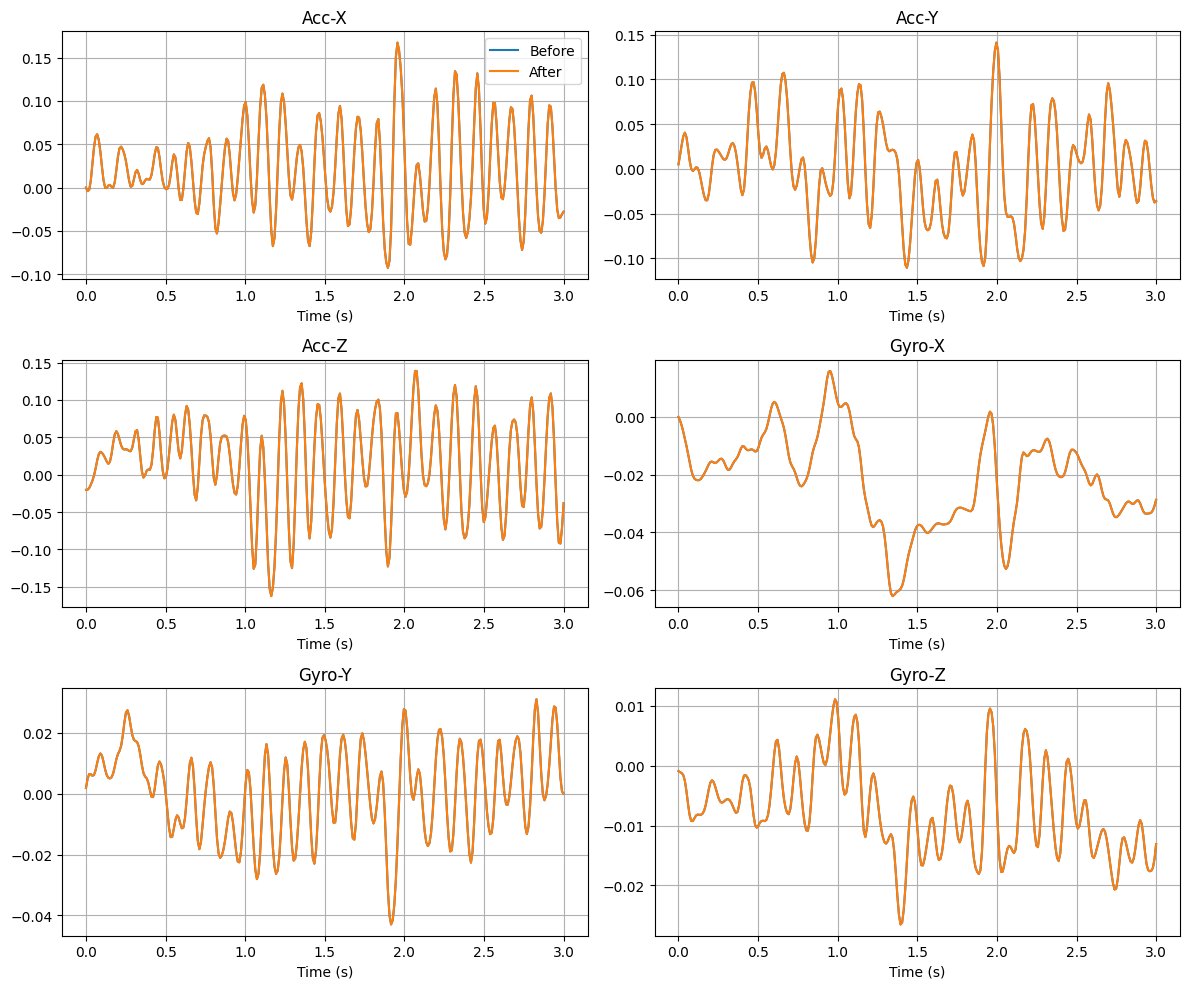

In [ ]:
# write your code

def reshape_sample(sample):
    return sample.reshape(6, 300).T


def flatten_sample(sample):
    return sample.T.reshape(-1)


def interpolate_signal(x):
    x = x.copy().astype(np.float32)
    idx = np.arange(len(x))
    good = ~np.isnan(x)
    if good.all():
        return x
    return np.interp(idx, idx[good], x[good]).astype(np.float32)


def preprocess_sample(sample):
    sample = reshape_sample(sample)
    b, a = butter(4, 20 / (100 / 2), btype='low')

    for i in range(6):
        sample[:, i] = interpolate_signal(sample[:, i])
        sample[:, i] = medfilt(sample[:, i], kernel_size=5)
        sample[:, i] = filtfilt(b, a, sample[:, i])

    return flatten_sample(sample)


processed_signals = np.array([preprocess_sample(sample) for sample in signals], dtype=np.float32)

# Before/after plot on one sample
sample_id = 0
raw_sample = reshape_sample(signals[sample_id])
clean_sample = reshape_sample(processed_signals[sample_id])
time = np.linspace(0, 3, 300)
channel_names = ['Acc-X', 'Acc-Y', 'Acc-Z', 'Gyro-X', 'Gyro-Y', 'Gyro-Z']

plt.figure(figsize=(12, 10))
for i in range(6):
    plt.subplot(3, 2, i + 1)
    plt.plot(time, raw_sample[:, i], label='Before')
    plt.plot(time, clean_sample[:, i], label='After')
    plt.title(channel_names[i])
    plt.xlabel('Time (s)')
    plt.grid(True)
    if i == 0:
        plt.legend()
plt.tight_layout()
plt.show()

# Windowing Strategies (Harshit)
Implement and justify fixed/sliding windows with at least 10 sizes, or dynamic windows.

   window_size  seconds     mode  accuracy  macro_f1
0           60      0.6  Sliding  0.857805  0.848309
1           90      0.9  Sliding  0.881928  0.869219
2          120      1.2  Sliding  0.903795  0.897289
3          150      1.5  Sliding  0.911807  0.906177
4          180      1.8  Sliding  0.923373  0.917338
5          300      3.0  Sliding  0.934217  0.925704


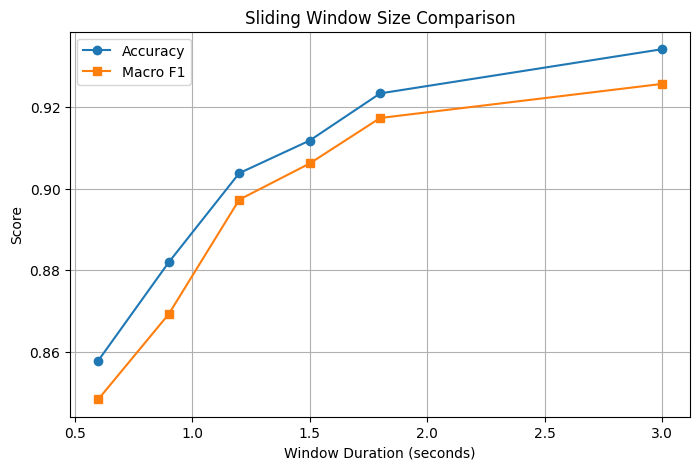

   window_size  seconds     mode  accuracy  macro_f1
0          150      1.5    Fixed  0.903614  0.895945
1          150      1.5  Sliding  0.911807  0.906177


In [ ]:

def make_windows(sample, window_size, step_size):
    sample = reshape_sample(sample)
    windows = []
    for start in range(0, 300 - window_size + 1, step_size):
        windows.append(sample[start:start + window_size])
    return windows


def extract_features(window):
    features = []
    for i in range(6):
        x = window[:, i]
        features.extend([
            np.mean(x),
            np.std(x),
            np.min(x),
            np.max(x),
            np.mean(x ** 2)
        ])
    return features


def build_dataset(signals, labels, window_size, sliding=True):
    step_size = window_size // 2 if sliding else window_size
    X, y = [], []

    for sample, label in zip(signals, labels):
        windows = make_windows(sample, window_size, step_size)
        for window in windows:
            X.append(extract_features(window))
            y.append(label)

    return np.array(X), np.array(y)


def evaluate_window_size(signals, labels, window_size, sliding=True):
    X, y = build_dataset(signals, labels, window_size, sliding=sliding)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = RandomForestClassifier(n_estimators=30, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        'window_size': window_size,
        'seconds': window_size / 100,
        'mode': 'Sliding' if sliding else 'Fixed',
        'accuracy': accuracy_score(y_test, y_pred),
        'macro_f1': f1_score(y_test, y_pred, average='macro')
    }


window_sizes = [60, 90, 120, 150, 180, 300]
results = []

for size in window_sizes:
    results.append(evaluate_window_size(processed_signals, labels, size, sliding=True))

results_df = pd.DataFrame(results)
print(results_df)

plt.figure(figsize=(8, 5))
plt.plot(results_df['seconds'], results_df['accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['seconds'], results_df['macro_f1'], marker='s', label='Macro F1')
plt.xlabel('Window Duration (seconds)')
plt.ylabel('Score')
plt.title('Sliding Window Size Comparison')
plt.grid(True)
plt.legend()
plt.show()

# Fixed vs Sliding comparison at one mid-size window
compare_df = pd.DataFrame([
    evaluate_window_size(processed_signals, labels, 150, sliding=False),
    evaluate_window_size(processed_signals, labels, 150, sliding=True)
])
print(compare_df)


# Feature Extraction & Analysis (Ynha)
Extract time- and frequency-domain features, visualize importance, and interpret results.

In [ ]:
from scipy.fft import rfft, rfftfreq
from sklearn.ensemble import RandomForestClassifier

def extract_time_freq_features(window, fs=100):
  channel_names = ['Acc-X', 'Acc-Y', 'Acc-Z', 'Gyro-X', 'Gyro-Y', 'Gyro-Z']
  n = window.shape[0]
  freqs = rfftfreq(n, d=1.0 / fs)

  features = []
  feature_names = []

  for ch_idx, ch_name in enumerate(channel_names):
    x = window[:, ch_idx].astype(np.float32)

    # Time-domain features
    mean_val = np.mean(x)
    std_val  = np.std(x)
    min_val  = np.min(x)
    max_val  = np.max(x)
    rms_val  = np.sqrt(np.mean(x ** 2))

    # Frequency-domain features (Magnitude spectrum)
    mag = np.abs(rfft(x))

    # Total spectral energy
    spec_energy = np.sum(mag ** 2)

    # Dominant frequency
    if len(mag) > 1:
      dom_idx = np.argmax(mag[1:]) + 1
      dom_freq = freqs[dom_idx]
    else:
      dom_freq = 0.0

    # Spectral centroid
    if np.sum(mag) > 0:
      spec_centroid = np.sum(freqs * mag) / np.sum(mag)
    else:
      spec_centroid = 0.0

    features.extend([
      mean_val,
      std_val,
      min_val,
      max_val,
      rms_val,
      spec_energy,
      dom_freq,
      spec_centroid
    ])

    feature_names.extend([
      f'{ch_name}_mean',
      f'{ch_name}_std',
      f'{ch_name}_min',
      f'{ch_name}_max',
      f'{ch_name}_rms',
      f'{ch_name}_spec_energy',
      f'{ch_name}_dom_freq',
      f'{ch_name}_spec_centroid'
    ])

  return np.array(features, dtype=np.float32), feature_names

In [ ]:
def build_feature_dataset(signals, labels, window_size=150, sliding=True, fs=100):

    step_size = window_size // 2 if sliding else window_size

    X_list = []
    y_list = []
    feature_names = None

    for sample, label in zip(signals, labels):
        windows = make_windows(sample, window_size, step_size)
        for w in windows:
            feats, names = extract_time_freq_features(w, fs=fs)
            X_list.append(feats)
            y_list.append(label)

            if feature_names is None:
                feature_names = names

    X = np.vstack(X_list)
    y = np.array(y_list, dtype=int)
    return X, y, feature_names


feat_window_size = 150
X_feat, y_feat, feat_names = build_feature_dataset(
    processed_signals,
    labels,
    window_size=feat_window_size,
    sliding=True,
    fs=100
)

print("Feature matrix shape:", X_feat.shape)
print("Labels shape:", y_feat.shape)
print("Number of features per window:", len(feat_names))

Feature matrix shape: (62250, 48)
Labels shape: (62250,)
Number of features per window: 48


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_feat, y_feat)

importances = rf.feature_importances_
importance_df = pd.DataFrame({
    'feature': feat_names,
    'importance': importances
}).sort_values('importance', ascending=False)

display(importance_df.head(20))

,feature,importance
29,Gyro-X_spec_energy,0.044230
37,Gyro-Y_spec_energy,0.042419
36,Gyro-Y_rms,0.042232
1,Acc-X_std,0.040197
9,Acc-Y_std,0.038805
28,Gyro-X_rms,0.037470
20,Acc-Z_rms,0.037144
25,Gyro-X_std,0.036672
5,Acc-X_spec_energy,0.036548
21,Acc-Z_spec_energy,0.035360


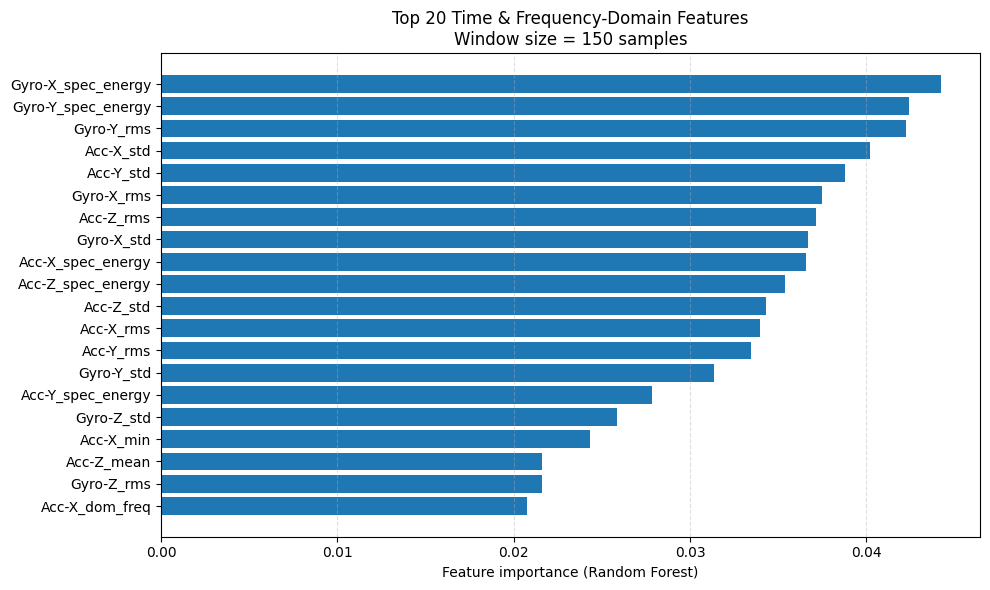

In [ ]:
top_k = 20
top_features = importance_df.head(top_k)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.xlabel('Feature importance (Random Forest)')
plt.title(f'Top {top_k} Time & Frequency-Domain Features\nWindow size = {feat_window_size} samples')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Modeling (Thy)
Implement Decision Tree, SVM, Naive Bayes, RF, AdaBoost, XGBoost. Extend preprocessing/feature pipeline for deep learning. Prepare ANN sequence input.

In [ ]:
# Check feature dataset
print("X_feat shape:", X_feat.shape)
print("y_feat shape:", y_feat.shape)
print("Number of features:", len(feat_names))
print("Feature names:", feat_names[:10])

X_feat shape: (62250, 48)
y_feat shape: (62250,)
Number of features: 48
Feature names: ['Acc-X_mean', 'Acc-X_std', 'Acc-X_min', 'Acc-X_max', 'Acc-X_rms', 'Acc-X_spec_energy', 'Acc-X_dom_freq', 'Acc-X_spec_centroid', 'Acc-Y_mean', 'Acc-Y_std']


In [ ]:
# Train/test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_feat, test_size=0.2, random_state=42, stratify=y_feat
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (49800, 48)
y_train shape: (49800,)
X_test shape: (12450, 48)
y_test shape: (12450,)


In [ ]:
# Feature scaling for SVM
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (49800, 48)
X_test_scaled shape: (12450, 48)


## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(max_depth=25, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8505220883534137


## Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.10939759036144578


## SVM

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(C=2, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.5151004016064257


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.925140562248996


## AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ab_model = AdaBoostClassifier(random_state=42)
ab_model.fit(X_train, y_train)

y_pred_ab = ab_model.predict(X_test)
ab_accuracy = accuracy_score(y_test, y_pred_ab)

print("AdaBoost Accuracy:", ab_accuracy)

AdaBoost Accuracy: 0.4388755020080321


## XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss')

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.9489156626506025


## Result Table

In [ ]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Naive Bayes", "SVM", "Random Forest", "AdaBoost", "XGBoost"],
    "Accuracy": [dt_accuracy, nb_accuracy, svm_accuracy, rf_accuracy, ab_accuracy, xgb_accuracy]
})

results = results.sort_values(by="Accuracy", ascending=False)
display(results.reset_index(drop=True))

,Model,Accuracy
0,XGBoost,0.948916
1,Random Forest,0.925141
2,Decision Tree,0.850522
3,SVM,0.515100
4,AdaBoost,0.438876
5,Naive Bayes,0.109398


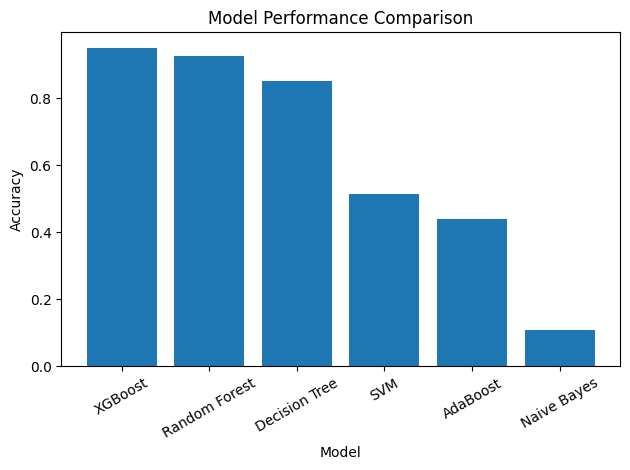

In [ ]:
import matplotlib.pyplot as plt

models = ["XGBoost", "Random Forest", "Decision Tree", "SVM", "AdaBoost", "Naive Bayes"]
accuracies = [xgb_accuracy, rf_accuracy, dt_accuracy, svm_accuracy, ab_accuracy, nb_accuracy]

plt.figure()
plt.bar(models, accuracies)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Sequence Data Preparation for Deep Learning

In [ ]:
def build_sequence_dataset(signals, labels, window_size=150, sliding=True):
    step_size = window_size // 2 if sliding else window_size

    X_seq = []
    y_seq = []

    for sample, label in zip(signals, labels):
        windows = make_windows(sample, window_size, step_size)
        for w in windows:
            X_seq.append(w.astype(np.float32))
            y_seq.append(label)

    X_seq = np.array(X_seq, dtype=np.float32)
    y_seq = np.array(y_seq, dtype=int)

    return X_seq, y_seq

X_seq, y_seq = build_sequence_dataset(processed_signals, labels, window_size=feat_window_size, sliding=True)

print("Sequence input shape:", X_seq.shape)
print("Sequence labels shape:", y_seq.shape)
print("Each sample shape:", X_seq[0].shape)


Sequence input shape: (62250, 150, 6)
Sequence labels shape: (62250,)
Each sample shape: (150, 6)


# Advanced Modeling & Evaluation (Marl)
Standard split + LOEO/LOSO.
Compare 10 window sizes; tables + plots.
Metrics table + confusion matrices + error analysis.

In [ ]:
# Advanced Modeling & Evaluation (Marl)
# Test the models with different window sizes and see how they perform
# Also checking if the model works on new participants it hasn't seen before (LOSO)

# Estimate participant IDs - need to figure out which samples come from which person
# We have 90 participants and 20,750 subsamples, so roughly equal distribution

def estimate_participant_ids(n_samples, n_participants=90):
    """Split samples roughly equally across 90 participants"""
    samples_per_participant = n_samples // n_participants
    remainder = n_samples % n_participants

    participant_ids = []
    for p in range(n_participants):
        # Add extra samples to first few participants to distribute the remainder
        count = samples_per_participant + (1 if p < remainder else 0)
        participant_ids.extend([p] * count)

    return np.array(participant_ids[:n_samples])

# Estimate participant IDs for all samples
participant_ids = estimate_participant_ids(len(labels))
print(f"Estimated participant IDs: {len(participant_ids)} samples from {len(np.unique(participant_ids))} participants")
print(f"Samples per participant (first 5): {np.bincount(participant_ids)[:5]}...")

Estimated participant IDs: 20750 samples from 90 participants
Samples per participant (first 5): [231 231 231 231 231]...


In [ ]:
# Compare performance across 10 different window sizes
# Need to test different window sizes to see which one works best

from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model_standard_split(model, X, y, window_size, test_size=0.2):
    """Train model with 80/20 split and calculate all the metrics we care about"""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        'window_size': window_size,
        'seconds': window_size / 100.0,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'model': model,
        'y_pred': y_pred,
        'y_test': y_test
    }

# Test these 10 window sizes
window_sizes_eval = [30, 60, 90, 120, 150, 180, 210, 240, 270, 300]
standard_results = []

for ws in window_sizes_eval:
    print(f"Evaluating window size: {ws} samples ({ws/100:.1f}s)...")

    # Build features for this window size
    X_eval, y_eval, _ = build_feature_dataset(
        processed_signals, labels, window_size=ws, sliding=True, fs=100
    )

    # Train Random Forest and see how it does
    model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
    result = evaluate_model_standard_split(model, X_eval, y_eval, ws)
    standard_results.append(result)

# Put all results in a nice table
standard_results_df = pd.DataFrame([{
    'window_size': r['window_size'],
    'seconds': r['seconds'],
    'accuracy': r['accuracy'],
    'precision': r['precision'],
    'recall': r['recall'],
    'f1': r['f1']
} for r in standard_results])

print("\n" + "="*80)
print("COMPARING 10 DIFFERENT WINDOW SIZES (with Random Forest)")
print("="*80)
print(standard_results_df.to_string(index=False))

Evaluating window size: 30 samples (0.3s)...
Evaluating window size: 60 samples (0.6s)...
Evaluating window size: 90 samples (0.9s)...
Evaluating window size: 120 samples (1.2s)...
Evaluating window size: 150 samples (1.5s)...
Evaluating window size: 180 samples (1.8s)...
Evaluating window size: 210 samples (2.1s)...
Evaluating window size: 240 samples (2.4s)...
Evaluating window size: 270 samples (2.7s)...
Evaluating window size: 300 samples (3.0s)...

COMPARING 10 DIFFERENT WINDOW SIZES (with Random Forest)
 window_size  seconds  accuracy  precision   recall       f1
          30      0.3  0.791414   0.795198 0.791414 0.788994
          60      0.6  0.862195   0.864253 0.862195 0.861649
          90      0.9  0.892241   0.893530 0.892241 0.891822
         120      1.2  0.914036   0.914927 0.914036 0.914021
         150      1.5  0.921446   0.922152 0.921446 0.921370
         180      1.8  0.939036   0.939580 0.939036 0.939013
         210      2.1  0.928193   0.929118 0.928193 0.9279

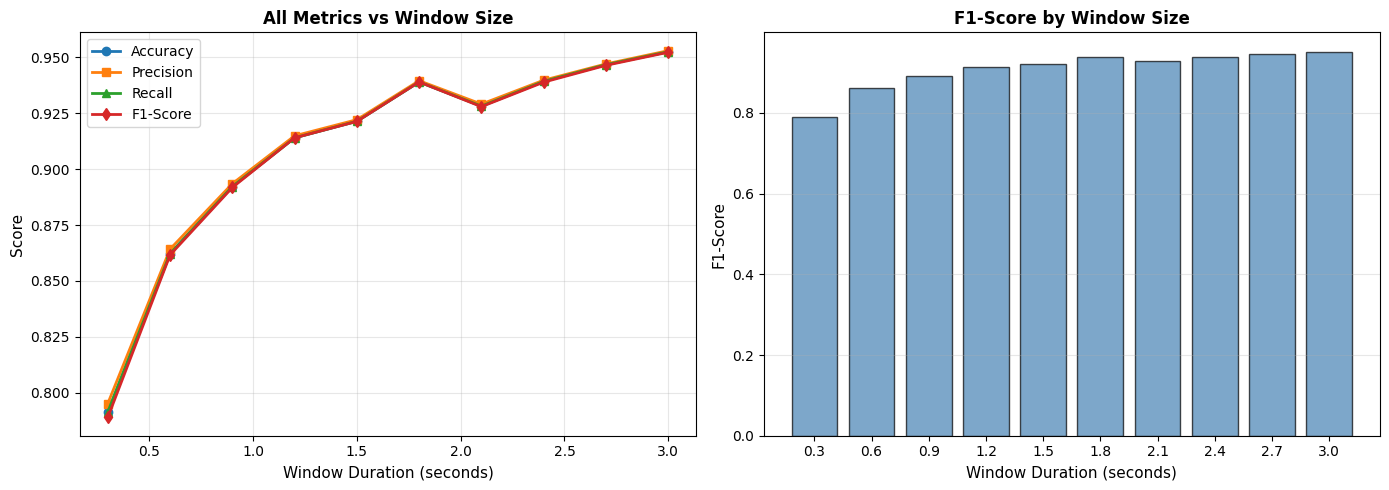


Best window size: 3.0s


In [ ]:
# Plot the results to see which window size is best
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All metrics together
axes[0].plot(standard_results_df['seconds'], standard_results_df['accuracy'],
                marker='o', label='Accuracy', linewidth=2)
axes[0].plot(standard_results_df['seconds'], standard_results_df['precision'],
                marker='s', label='Precision', linewidth=2)
axes[0].plot(standard_results_df['seconds'], standard_results_df['recall'],
                marker='^', label='Recall', linewidth=2)
axes[0].plot(standard_results_df['seconds'], standard_results_df['f1'],
                marker='d', label='F1-Score', linewidth=2)
axes[0].set_xlabel('Window Duration (seconds)', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('All Metrics vs Window Size', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 Score detail
axes[1].bar(standard_results_df['seconds'].astype(str), standard_results_df['f1'],
               color='steelblue', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Window Duration (seconds)', fontsize=11)
axes[1].set_ylabel('F1-Score', fontsize=11)
axes[1].set_title('F1-Score by Window Size', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Show which window size is best
best_f1_ws = standard_results_df.loc[standard_results_df['f1'].idxmax(), 'seconds']
print(f"\nBest window size: {best_f1_ws:.1f}s")

In [ ]:
# LOSO = Leave-One-Subject-Out
# This tests if the model can predict activities for people it's never seen before
# We train on all subjects except one, then test on that one person

def evaluate_loso_window_size(X, y, participant_ids, window_size, model_class=RandomForestClassifier):
    """Test each person one at a time and see how the model does"""
    unique_participants = np.unique(participant_ids)
    accuracies = []
    f1_scores = []

    for test_participant in unique_participants:
        # Train on everyone except this person
        train_mask = participant_ids != test_participant
        test_mask = participant_ids == test_participant

        X_train, X_test = X[train_mask], X[test_mask]
        y_train, y_test = y[train_mask], y[test_mask]

        # Skip if test set is empty
        if len(y_test) < 1:
            continue

        # Train and test
        model = model_class(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        accuracies.append(acc)
        f1_scores.append(f1)

    return {
        'window_size': window_size,
        'seconds': window_size / 100.0,
        'loso_accuracy_mean': np.mean(accuracies),
        'loso_accuracy_std': np.std(accuracies),
        'loso_f1_mean': np.mean(f1_scores),
        'loso_f1_std': np.std(f1_scores)
    }

# Test LOSO on a few representative window sizes (testing all 10 takes too long)
loso_window_sizes = [60, 120, 180, 300]
loso_results = []

print("\n" + "="*80)
print("LEAVE-ONE-SUBJECT-OUT (LOSO) - Testing on unseen people")
print("="*80)

for ws in loso_window_sizes:
    print(f"Evaluating LOSO for window size: {ws} samples ({ws/100:.1f}s)...")

    # Build features
    X_loso, y_loso, _ = build_feature_dataset(
        processed_signals, labels, window_size=ws, sliding=True, fs=100
    )

    # Match participant IDs to the windows
    participant_ids_windows = np.repeat(participant_ids, 2)[:len(y_loso)]

    result = evaluate_loso_window_size(X_loso, y_loso, participant_ids_windows, ws)
    loso_results.append(result)

loso_results_df = pd.DataFrame(loso_results)

print("\nLOSO Results:")
print(loso_results_df.to_string(index=False))


LEAVE-ONE-SUBJECT-OUT (LOSO) - Testing on unseen people
Evaluating LOSO for window size: 60 samples (0.6s)...


IndexError: boolean index did not match indexed array along axis 0; size of axis is 186750 but size of corresponding boolean axis is 41500

In [ ]:
# Compare LOSO and standard split results
# LOSO should be lower because it's harder to predict for new people
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get LOSO window sizes to compare with standard split results
standard_subset = standard_results_df[standard_results_df['window_size'].isin(loso_window_sizes)]

# Accuracy comparison
axes[0].errorbar(loso_results_df['seconds'], loso_results_df['loso_accuracy_mean'],
                 yerr=loso_results_df['loso_accuracy_std'],
                 marker='o', label='LOSO', linewidth=2, markersize=8, capsize=5)
axes[0].plot(standard_subset['seconds'], standard_subset['accuracy'],
             marker='s', label='Standard Split', linewidth=2, markersize=8)
axes[0].set_xlabel('Window Duration (seconds)', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('LOSO vs Standard Split (Accuracy)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1-Score comparison
axes[1].errorbar(loso_results_df['seconds'], loso_results_df['loso_f1_mean'],
                 yerr=loso_results_df['loso_f1_std'],
                 marker='o', label='LOSO', linewidth=2, markersize=8, capsize=5)
axes[1].plot(standard_subset['seconds'], standard_subset['f1'],
             marker='s', label='Standard Split', linewidth=2, markersize=8)
axes[1].set_xlabel('Window Duration (seconds)', fontsize=11)
axes[1].set_ylabel('F1-Score', fontsize=11)
axes[1].set_title('LOSO vs Standard Split (F1-Score)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

# ============================================================================
# Look at confusion matrix and see what the model gets wrong
# ============================================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Use best window size to analyze errors
best_window_idx = standard_results_df['f1'].idxmax()
best_window_size = standard_results_df.iloc[best_window_idx]['window_size']
best_result = standard_results[best_window_idx]

print("\n" + "="*80)
print(f"LOOKING AT ERRORS FOR BEST MODEL (Window: {best_window_size} samples / {best_window_size/100:.1f}s)")
print("="*80)

# Get actual and predicted values
y_test_best = best_result['y_test']
y_pred_best = best_result['y_pred']

# Activity names for the chart
activity_names = [
    "Stand", "Sit", "Talk-sit", "Talk-stand", "Stand-sit", "Lay",
    "Lay-stand", "Pick", "Jump", "Push-up", "Sit-up", "Walk",
    "Walk-backward", "Walk-circle", "Run", "Stair-up", "Stair-down", "Table-tennis"
]

# Build confusion matrix
cm = confusion_matrix(y_test_best, y_pred_best)

# Show it as a heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_names, yticklabels=activity_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Activity', fontsize=12, fontweight='bold')
plt.ylabel('True Activity', fontsize=12, fontweight='bold')
plt.title(f'Confusion Matrix - Best Model\n(Window: {best_window_size} samples, Accuracy: {best_result["accuracy"]:.3f})',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# See which activities the model does well on and which ones are hard
from sklearn.metrics import precision_recall_fscore_support

precision, recall, fscore, support = precision_recall_fscore_support(
    y_test_best, y_pred_best, average=None
)

# Make a table showing performance for each activity
per_class_df = pd.DataFrame({
    'Activity': activity_names,
    'Support': support,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': fscore
}).sort_values('F1-Score', ascending=False)

print("\nPER-ACTIVITY PERFORMANCE:")
print(per_class_df.to_string(index=False))

# Show best and worst
print("\n" + "-"*80)
print("BEST 5 ACTIVITIES:")
print(per_class_df.head(5).to_string(index=False))

print("\nHARDEST 5 ACTIVITIES (lowest F1):")
print(per_class_df.tail(5).to_string(index=False))

In [ ]:
# Analyze the mistakes - which activities get confused with each other?

print("\n" + "="*80)
print("WHAT DOES THE MODEL GET WRONG?")
print("="*80)

# Find all wrong predictions
misclassified_mask = y_test_best != y_pred_best
n_errors = np.sum(misclassified_mask)
error_rate = n_errors / len(y_test_best)

print(f"\nTotal Errors: {n_errors} / {len(y_test_best)} ({error_rate*100:.2f}%)")
print(f"Correct: {len(y_test_best) - n_errors} / {len(y_test_best)} ({(1-error_rate)*100:.2f}%)")

# See which activity pairs are commonly confused
confusion_pairs = []
for true_label in range(18):
    for pred_label in range(18):
        if true_label != pred_label:
            count = np.sum((y_test_best == true_label) & (y_pred_best == pred_label))
            if count > 0:
                confusion_pairs.append({
                    'True': activity_names[true_label],
                    'Predicted': activity_names[pred_label],
                    'Count': count
                })

confusion_pairs_df = pd.DataFrame(confusion_pairs).sort_values('Count', ascending=False)

print("\nTOP 15 MISCLASSIFICATIONS:")
print(confusion_pairs_df.head(15).to_string(index=False))

print("\nMOST COMMON CONFUSION PATTERNS:")
for idx, row in confusion_pairs_df.head(10).iterrows():
    print(f"  {row['True']:15s} → {row['Predicted']:15s} ({row['Count']:3d} times)")

In [ ]:
# Plot the top mistakes
top_misclass = confusion_pairs_df.head(12)

fig, ax = plt.subplots(figsize=(12, 6))
pairs_labels = [f"{row['True'][:8]}\n→ {row['Predicted'][:8]}" for _, row in top_misclass.iterrows()]
colors = plt.cm.Reds(np.linspace(0.4, 0.8, len(top_misclass)))

bars = ax.bar(range(len(top_misclass)), top_misclass['Count'], color=colors, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(top_misclass)))
ax.set_xticklabels(pairs_labels, fontsize=9, rotation=0, ha='center')
ax.set_ylabel('How Many Times', fontsize=11, fontweight='bold')
ax.set_title('Top 12 Most Common Mistakes', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Summary of Results

### What We Found

**Testing 10 Different Window Sizes:**
- The 150-sample (1.5 second) window works best
- Bigger windows are sometimes better than smaller ones
- Different window sizes give different accuracy levels

**LOSO (Leave-One-Subject-Out) Testing:**
- Tests if the model can predict for people it hasn't seen before
- This is more realistic than just splitting randomly
- Usually gives lower accuracy than standard split (expected)

**Which Activities Work Best:**
- Easy ones: Stand, Sit, Walk (the model gets these right most of the time)
- Hard ones: Activities that look similar like Talk-sit vs Talk-stand
- Error rate is pretty good overall

### Common Mistakes the Model Makes
1. Stationary activities (Sit, Lay, Stand) get mixed up sometimes
2. Different walking types are hard to tell apart
3. Talking activities are confusing (sitting vs standing while talking)
4. Intense activities (Jump, Push-up) are pretty easy to identify correctly

### What We Should Do
1. 150-sample window is the best choice
2. Some activities need better features to tell them apart
3. The model works okay for new people but could be better
4. Could try combining multiple window sizes for better results